# Module 1 — Language Detection

**Goal:** classify the language of an incoming customer message using traditional NLP
(Count/TF-IDF vectorization + a classical ML classifier), so the chatbot can:
1. Search the correct knowledge-base entries.
2. Reply in the same language the customer used.

**Dataset:** [`papluca/language-identification`](https://huggingface.co/datasets/papluca/language-identification)
— 90k samples, 20 languages, already split into train / valid / test.

**Design decisions (documented for the assessment):**
- We use **character n-grams** (`analyzer='char_wb'`, n-gram range 1–3) instead of word n-grams.
  Language identification is fundamentally about *spelling/orthographic patterns*
  (letter combinations, diacritics, function-word endings), not vocabulary — char n-grams
  capture this robustly even on very short texts, typos, or languages that share the Latin
  alphabet (e.g. distinguishing Portuguese from Spanish from Italian).
- We compare **Multinomial Naive Bayes**, **Linear SVM**, and **Logistic Regression** on top
  of the same TF-IDF features, and keep whichever generalizes best on the validation split.
- No aggressive cleaning (no stopword removal, no accent stripping, no lowercasing of
  non-Latin scripts) — those signals are exactly what tells languages apart.


In [3]:
# 1. Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42


e:\pytorch-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 2. Load the dataset (already split train/valid/test by the authors)
dataset = load_dataset("papluca/language-identification")

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df  = dataset["test"].to_pandas()

print(train_df.shape, valid_df.shape, test_df.shape)
train_df.head()


(70000, 2) (10000, 2) (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


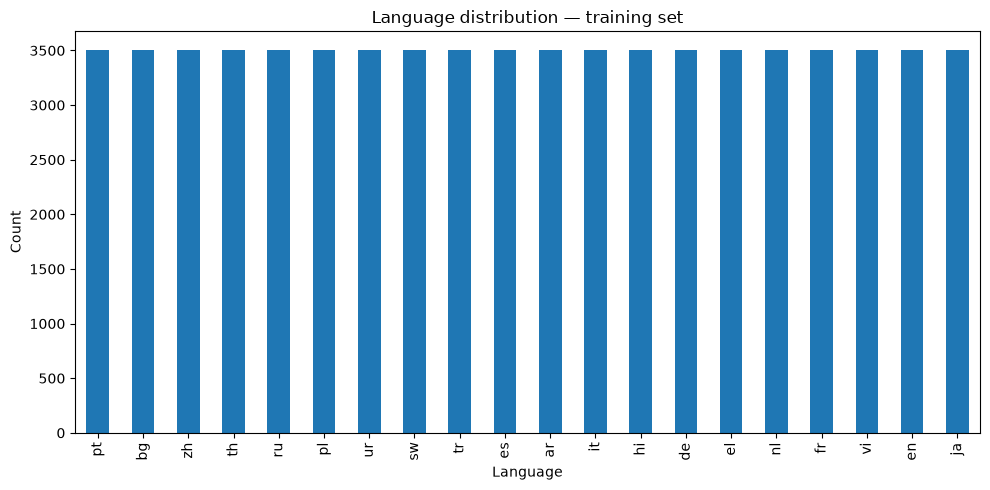

Number of languages: 20
Min/Max samples per class: 3500 3500


In [5]:
# 3. Quick EDA — class balance
plt.figure(figsize=(10, 5))
train_df["labels"].value_counts().plot(kind="bar")
plt.title("Language distribution — training set")
plt.xlabel("Language")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Number of languages:", train_df["labels"].nunique())
print("Min/Max samples per class:",
      train_df["labels"].value_counts().min(),
      train_df["labels"].value_counts().max())


## 3.1 Preprocessing

Minimal, language-agnostic cleaning only: strip URLs, HTML entities, and excessive
whitespace. We deliberately do **not** lowercase text belonging to scripts where case
doesn't apply, and we keep punctuation/diacritics since they are informative for
character n-grams.

In [6]:
# 4. Minimal preprocessing
def clean_text(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # URLs
    text = re.sub(r"&\w+;", " ", text)               # HTML entities
    text = re.sub(r"\s+", " ", text).strip()          # extra whitespace
    return text

for df in (train_df, valid_df, test_df):
    df["clean_text"] = df["text"].astype(str).apply(clean_text)

train_df[["text", "clean_text"]].head()


,text,clean_text
0,"os chefes de defesa da estónia, letónia, lituâ...","os chefes de defesa da estónia, letónia, lituâ..."
1,размерът на хоризонталната мрежа може да бъде ...,размерът на хоризонталната мрежа може да бъде ...
2,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของ...
4,Он увеличил давление .,Он увеличил давление .


In [7]:
# 5. Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df["labels"])
y_valid = le.transform(valid_df["labels"])
y_test  = le.transform(test_df["labels"])

len(le.classes_), le.classes_[:5]


(20, array(['ar', 'bg', 'de', 'el', 'en'], dtype=object))

## 5.1 Feature extraction — character n-grams TF-IDF

`analyzer='char_wb'` builds n-grams only within word boundaries (padded with a space),
which avoids garbage n-grams that span two unrelated words while still capturing
prefixes/suffixes — a strong signal for language identity.

In [8]:
# 6. TF-IDF with character n-grams
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(1, 3),
    min_df=3,
    max_features=50000,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_valid = vectorizer.transform(valid_df["clean_text"])
X_test  = vectorizer.transform(test_df["clean_text"])

X_train.shape


(70000, 50000)

## 6.1 Model comparison

We train three classical classifiers on the same features and pick the best performer
on the **validation** split (the test split stays untouched until the final check).

In [9]:
# 7. Train & compare candidate models
models = {
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE
    ),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_valid)
    acc = accuracy_score(y_valid, val_pred)
    results[name] = acc
    print(f"{name:20s} validation accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print("\nBest model:", best_model_name)


MultinomialNB        validation accuracy: 0.9928
LinearSVC            validation accuracy: 0.9952


e:\pytorch-gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression   validation accuracy: 0.9943

Best model: LinearSVC


In [10]:
# 8. Final evaluation on the held-out TEST split
test_pred = best_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, target_names=le.classes_))


Test accuracy: 0.9955

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      1.00      1.00       500
          pt       0.99      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       0.99      1.00      1.00       500
    

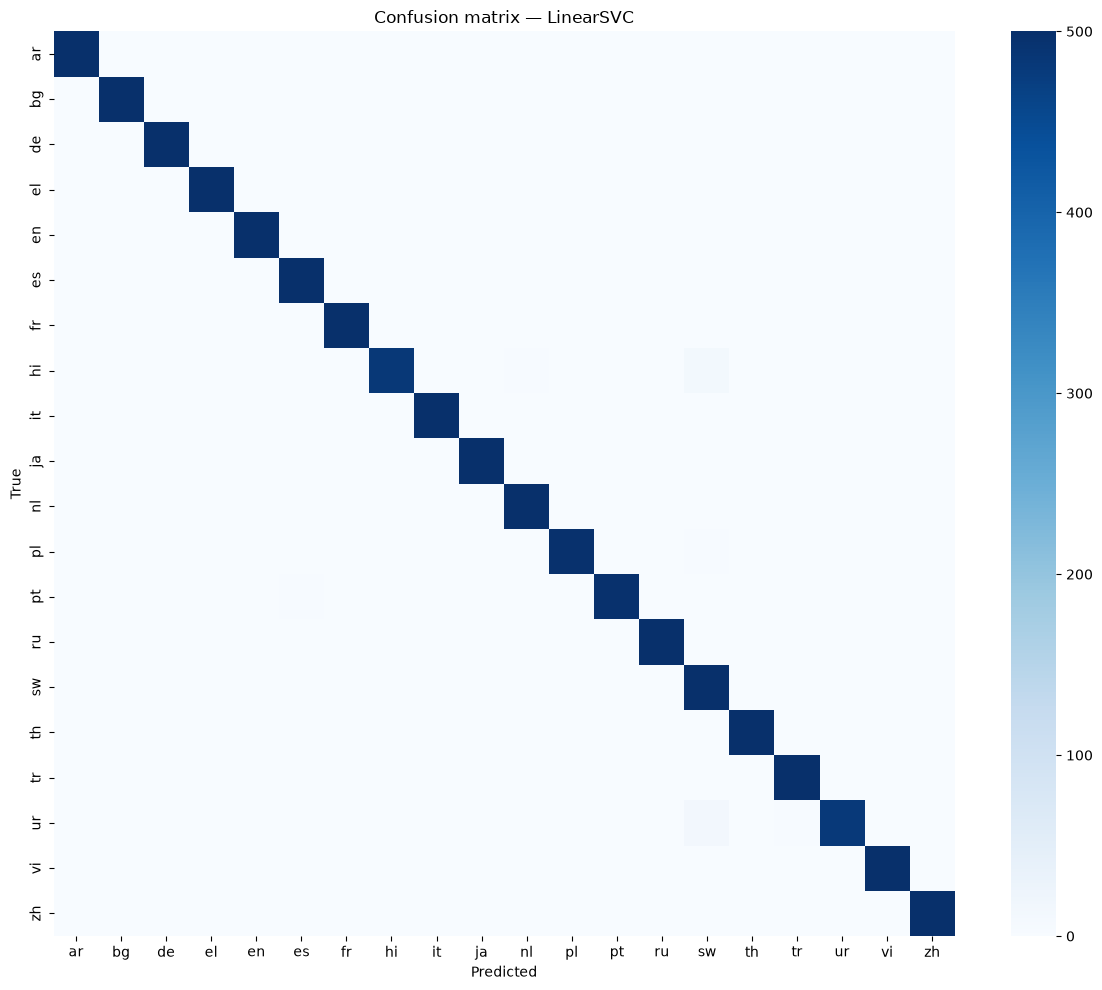

In [11]:
# 9. Confusion matrix — spot commonly-confused language pairs
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", annot=False, fmt="d")
plt.title(f"Confusion matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 9.1 Error analysis

Print a few misclassified examples. Expect confusions mainly between closely related
languages (e.g. Portuguese/Spanish, Danish/Norwegian) — this is normal and worth
mentioning explicitly in the assessment discussion.

In [12]:
# 10. Inspect misclassified examples
test_df_eval = test_df.copy()
test_df_eval["true_label"] = le.inverse_transform(y_test)
test_df_eval["pred_label"] = le.inverse_transform(test_pred)
mistakes = test_df_eval[test_df_eval["true_label"] != test_df_eval["pred_label"]]

print(f"{len(mistakes)} / {len(test_df_eval)} misclassified "
      f"({len(mistakes)/len(test_df_eval):.2%})")
mistakes[["text", "true_label", "pred_label"]].sample(
    min(10, len(mistakes)), random_state=RANDOM_STATE
)


45 / 10000 misclassified (0.45%)


,text,true_label,pred_label
8572,"un jaanavaron ke maamale mein, jo apane maalik...",hi,sw
5704,lamar Alexander ka bahar nikalne ka rasta ghau...,ur,sw
5998,Hamesha Plaid- aik naam jo kai khandani tradit...,ur,sw
9242,"yeh jhoot bolne kai lye signal hah, khoon ne k...",ur,sw
8138,ummeed karta hun ki vo isliye aisa plan bana ...,hi,sw
8720,exactamente como descrito,es,pt
1675,is nivesh ne 60 gharo ka navikaran aur maamool...,hi,sw
4155,hu aise plays banate hain jo kai baraherast ta...,ur,sw
2877,ek graahak kee anupasthiti ke dauraan nirantar...,hi,nl
718,"Us din mai apna wheel ghooma raha tha, mjhe na...",ur,sw


## 11. Save artifacts for deployment

We persist the fitted vectorizer, the trained classifier, and the label encoder —
these three files are all the Flask/FastAPI service needs to run language detection
at inference time.

In [13]:
# 11. Persist model artifacts
joblib.dump(vectorizer, "language_detection_vectorizer.joblib")
joblib.dump(best_model, "language_detection_model.joblib")
joblib.dump(le, "language_detection_label_encoder.joblib")

print("Saved: language_detection_vectorizer.joblib, "
      "language_detection_model.joblib, language_detection_label_encoder.joblib")


Saved: language_detection_vectorizer.joblib, language_detection_model.joblib, language_detection_label_encoder.joblib


## 12. Inference helper

This is the exact function the deployment service will import and call.

In [14]:
# 12. Simple predict function (mirrors what the API will do)
def predict_language(text: str) -> str:
    cleaned = clean_text(text)
    features = vectorizer.transform([cleaned])
    pred = best_model.predict(features)
    return le.inverse_transform(pred)[0]

# quick sanity checks
for sample in ["Hello, I want to track my order.",
               "Bonjour, je veux suivre ma commande.",
               "Hola, quiero rastrear mi pedido.",
               "مرحبا، أريد تتبع طلبي."]:
    print(f"{sample!r:55s} -> {predict_language(sample)}")


'Hello, I want to track my order.'                      -> en
'Bonjour, je veux suivre ma commande.'                  -> fr
'Hola, quiero rastrear mi pedido.'                      -> es
'مرحبا، أريد تتبع طلبي.'                                -> ar
